**1.1**. (С использованием JupyterNotebook) Найти общее решение системы линейных уравнений
x1 + 5x2 − 2x3 = −7,

−3x1 + x2 + 9x3 − 5x4 = 9,

4x1 − 8x2 − x3 + 7x4 = 0.

In [18]:
import numpy as np
import scipy.linalg as la
from sympy import *
init_printing()

A = np.array([[1, 5, -2, 0], [-3, 1, 9, -5], [4, -8, -1, 7]])

b = np.array([-7, 9, 0]).reshape(3, 1)

A_b = np.hstack([A, b])

Matrix(A_b).rref()

⎛⎡1  0  0  8/7   -11/7⎤           ⎞
⎜⎢                    ⎥           ⎟
⎜⎢0  1  0  -2/7  -6/7 ⎥, (0, 1, 2)⎟
⎜⎢                    ⎥           ⎟
⎝⎣0  0  1  -1/7   4/7 ⎦           ⎠

**1.2** Дана система линейных уравнений:
\begin{cases}
5x_1 - x_2 + 5x_3 + 9x_4 - 2x_5 = -3,\\
3x_1 + 0x_2 + 6x_3 + 9x_4 - x_5 = 4,\\
2x_1 + 0x_2 + 4x_3 + 6x_4 - x_5 = 0.\\
\end{cases}
Требуется найти:\
а)rref(A∣b) (приведённый ступенчатый вид расширенной матрицы);\
б)общее решение системы линейных уравнений

In [19]:
from sympy import symbols, Matrix, linsolve, latex
from IPython.display import display, Math

# Переменные для красивого вывода
x1, x2, x3, x4, x5 = symbols('x1 x2 x3 x4 x5')
variables = [x1, x2, x3, x4, x5]

# Расширенная матрица (A|b)
A_b = Matrix([
    [5, -1, 5, 9, -2, -3],
    [3,  0, 6, 9, -1,  4],
    [2,  0, 4, 6, -1,  0]
])

# rref матрицы и индексы базисных столбцов
rref_matrix, pivot_cols = A_b.rref()

# Вывод пункта а)
print("a) rref(A|b):")
display(rref_matrix)

# Форматируем красивый вывод в виде формулы
solution = list(linsolve(A_b, variables))[0]
sol_latex = "; ".join([latex(comp) for comp in solution])
display(Math(f"\\text{{б) }} x = ({sol_latex})"))

a) rref(A|b):


⎡1  0  2  3  0  4⎤
⎢                ⎥
⎢0  1  5  6  0  7⎥
⎢                ⎥
⎣0  0  0  0  1  8⎦

<IPython.core.display.Math object>

**1.3** Дана система линейных уравнений:
$$\begin{cases}
32x + 97y + 90z + 48u = 47, \\
35x + 84y + 91z + 54u = 40, \\
17x + 18y + 21z + 13u = 37.
\end{cases}$$
Требуется:
1) Объяснить, почему переменную $y$ можно представить как функцию от $x$ вида $y = a + bx$, где $a$ и $b$ — константы, зависящие только от коэффициентов исходной системы;
2) Найти константу $a$;
3) Найти константу $b$.

1. Если рассматривать столбцы с коэффициентами при переменных z и u, мы получим 
$$\begin{pmatrix}
90 & 48 \\
91 & 54 \\
21 & 13
\end{pmatrix}$$
Ранг такой матрицы $\le 2$, $\Rightarrow$ строки данной матрицы линейно зависимы $\Rightarrow$ существует ненулевой вектор-строка 
$$\begin{pmatrix}
a & b & c 
\end{pmatrix}$$
такой, что полностью обнуляет коэффициенты при z и u. Исходя из этого переменную y можно будет выразить через x, при условии ненулевого коэффициента при y.


In [20]:
from sympy import symbols, Eq, solve, Poly
from IPython.display import display, Math

# Переменные для красивого вывода
x, y, z, u = symbols('x y z u')

# Уравнения системы
eq1 = Eq(32*x + 97*y + 90*z + 48*u, 47)
eq2 = Eq(35*x + 84*y + 91*z + 54*u, 40)
eq3 = Eq(17*x + 18*y + 21*z + 13*u, 37)

# Выражаем y, z, u через x
sol = solve([eq1, eq2, eq3], (y, z, u))
y_expr = sol[y]

# Представляем y(x) в виде многочлена от x для извлечения коэффициентов
poly_y = Poly(y_expr, x)
b = poly_y.coeff_monomial(x)  # коэффициент при x^1
a = poly_y.coeff_monomial(1)  # свободный член (x^0)

# Красивый вывод формулы
display(Math(f"y = {a} + ({b})x"))

<IPython.core.display.Math object>

**1.4** Выполнить действия:
$$\begin{pmatrix}
3 & 0 & 2 \\
0 & 1 & 3 \\
2 & 2 & 0 \\
0 & 1 & 0
\end{pmatrix}
\cdot
\begin{pmatrix}
1 & 2 & -1 & 2 \\
-2 & -1 & 1 & 2 \\
2 & 1 & 1 & 2
\end{pmatrix}
+
\begin{pmatrix}
0 & -4 & 6 & 1 \\
2 & 2 & -5 & -2 \\
2 & -2 & 6 & 4 \\
1 & 3 & 0 & 1
\end{pmatrix}$$

In [21]:
from sympy import Matrix, latex
from IPython.display import display, Math

# Задаем исходные матрицы
A = Matrix([
    [3, 0, 2],
    [0, 1, 3],
    [2, 2, 0],
    [0, 1, 0]
])

B = Matrix([
    [ 1,  2, -1, 2],
    [-2, -1,  1, 2],
    [ 2,  1,  1, 2]
])

C = Matrix([
    [0, -4,  6,  1],
    [2,  2, -5, -2],
    [2, -2,  6,  4],
    [1,  3,  0,  1]
])

# Выполняем действия
result = A * B + C

# Красивый вывод результата
display(Math(f"{latex(A)} \\cdot {latex(B)} + {latex(C)} = {latex(result)}"))

<IPython.core.display.Math object>

**1.5** Найдите определители порядка $n$, элементы которого заданы условием:

а) $a_{ij} = \min(i, j)$;  
б) $a_{ij} = \max(i, j)$;  
в)* $a_{ij} = |i - j|$.

### **Аналитическое решение**

#### **а) $a_{ij} = \min(i, j)$**
Запишем матрицу $A$:
$$A = \begin{pmatrix}
1 & 1 & 1 & \dots & 1 \\
1 & 2 & 2 & \dots & 2 \\
1 & 2 & 3 & \dots & 3 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & 2 & 3 & \dots & n
\end{pmatrix}$$

Выполним элементарные преобразования строк: из каждой $k$-й строки вычтем предыдущую $(k-1)$-ю строку последовательно снизу вверх.

Матрица приводится к верхнетреугольному виду с единицами на главной диагонали:
$$\det(A) = \begin{vmatrix}
1 & 1 & 1 & \dots & 1 \\
0 & 1 & 1 & \dots & 1 \\
0 & 0 & 1 & \dots & 1 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \dots & 1
\end{vmatrix} = 1 \cdot 1 \cdots 1 = \mathbf{1}$$

$$\mathbf{\det(A) = 1}$$

---

#### **б) $a_{ij} = \max(i, j)$**
Запишем матрицу $B$:
$$B = \begin{pmatrix}
1 & 2 & 3 & \dots & n \\
2 & 2 & 3 & \dots & n \\
3 & 3 & 3 & \dots & n \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
n & n & n & \dots & n
\end{pmatrix}$$

Вычтем из каждой $k$-й строки следующую $(k+1)$-ю строку сверху вниз.

Получаем матрицу:
$$\det(B) = \begin{vmatrix}
-1 & 0 & 0 & \dots & 0 & 0 \\
-1 & -1 & 0 & \dots & 0 & 0 \\
\vdots & \vdots & \ddots & & \vdots & \vdots \\
-1 & -1 & -1 & \dots & -1 & 0 \\
n & n & n & \dots & n & n
\end{vmatrix}$$

В последнем столбце остался только один ненулевой элемент — $b_{nn} = n$. Разложим определитель по последнему столбцу:
$$\det(B) = (-1)^{n+n} \cdot n \cdot M_{nn} = n \cdot M_{nn}$$
Минор $M_{nn}$ — это нижнетреугольный определитель порядка $(n-1)$, на главной диагонали которого стоят $(-1)$:
$$M_{nn} = \begin{vmatrix}
-1 & 0 & \dots & 0 \\
-1 & -1 & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
-1 & -1 & \dots & -1
\end{vmatrix} = (-1)^{n-1}$$

Следовательно:
$$\mathbf{\det(B) = (-1)^{n-1} n}$$

---

#### **в)* $a_{ij} = |i - j|$**
Запишем матрицу $C$:
$$C = \begin{pmatrix}
0 & 1 & 2 & 3 & \dots & n-1 \\
1 & 0 & 1 & 2 & \dots & n-2 \\
2 & 1 & 0 & 1 & \dots & n-3 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots \\
n-1 & n-2 & n-3 & n-4 & \dots & 0
\end{pmatrix}$$

1. При $n = 1$: $\det(C) = |0| = 0$.
2. При $n \ge 2$:  
   Выполним последовательное вычитание строк: из каждой строки, начиная с последней, вычтем предыдущую. Получим 1 до главной диагонали, -1 на и после главной диагонали.
   
   Затем повторим эту же операцию ещё раз. После останутся 2, на каждой строке под главной диаганалью получатся 2 (всего n-2 двоек), остальные 1 и -1 занулятся.
   
   Последовательно раскладывая определитель по этим строкам, выносится множитель $2^{n-2}$, а оставшийся минор размера $2 \times 2$ даёт:
   $$\begin{vmatrix} 0 & n-1 \\ 1 & -1 \end{vmatrix} = -(n-1)$$

С учётом знаков перестановок и разложений получаем:
$$\mathbf{\det(C) = (-1)^{n-1} (n - 1) 2^{n - 2}} \quad (n \ge 1)$$

In [22]:
from sympy import Matrix, symbols, Function, init_printing
from IPython.display import display, Math

# Функция для вычисления определителей порядка n
def solve_1_5(n):
    # а) a_ij = min(i, j)
    A = Matrix(n, n, lambda i, j: min(i + 1, j + 1))
    
    # б) a_ij = max(i, j)
    B = Matrix(n, n, lambda i, j: max(i + 1, j + 1))
    
    # в) a_ij = |i - j|
    C = Matrix(n, n, lambda i, j: abs(i - j))
    
    return A.det(), B.det(), C.det()

# Проверим формулы для нескольких значений n (от 1 до 5)
print("Проверка вычислением для n от 1 до 5:")
for n in range(1, 6):
    det_a, det_b, det_c = solve_1_5(n)
    print(f"n = {n}: det(A) = {det_a}, det(B) = {det_b}, det(C) = {det_c}")

# Красивый вывод общих аналитических формул
display(Math(r"\text{Ответ:}"))
display(Math(r"\text{а) } \det(A) = 1"))
display(Math(r"\text{б) } \det(B) = (-1)^{n-1} n"))
display(Math(r"\text{в) } \det(C) = (-1)^{n-1} (n - 1) 2^{n - 2}"))

Проверка вычислением для n от 1 до 5:
n = 1: det(A) = 1, det(B) = 1, det(C) = 0
n = 2: det(A) = 1, det(B) = -2, det(C) = -1
n = 3: det(A) = 1, det(B) = 3, det(C) = 4
n = 4: det(A) = 1, det(B) = -4, det(C) = -12
n = 5: det(A) = 1, det(B) = 5, det(C) = 32


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**1.6** Найдите наибольшее значение определителя шестого порядка, составленного из чисел $-1$, $0$ и $1$. (Можно перебором).

In [23]:
import numpy as np
from sympy import Matrix, latex
from IPython.display import display, Math

# 1. Алгоритм локального поиска (перебор с улучшением)
def find_max_det_order_6(num_restarts=30):
    best_det = 0
    best_matrix = None
    
    for _ in range(num_restarts):
        # Начинаем со случайной матрицы из элементов {-1, 1}
        A = np.random.choice([-1, 1], size=(6, 6))
        current_det = abs(int(round(np.linalg.det(A))))
        
        # Локальный перебор (инвертируем элементы по одному)
        improved = True
        while improved:
            improved = False
            for i in range(6):
                for j in range(6):
                    A[i, j] = -A[i, j]
                    d = abs(int(round(np.linalg.det(A))))
                    if d > current_det:
                        current_det = d
                        improved = True
                    else:
                        A[i, j] = -A[i, j]  # откат
                        
        if current_det > best_det:
            best_det = current_det
            best_matrix = A.copy()
                
    return best_det, Matrix(best_matrix)

# 2. Поиск максимального определителя
max_det, max_matrix = find_max_det_order_6()

# 3. Вывод результатов
display(Math(r"\text{Пример матрицы с максимальным определителем } A_{\max}:"))
display(Math(f"A_{{\\max}} = {latex(max_matrix)}"))
display(Math(f"\\det(A_{{\\max}}) = {max_det}"))

print(f"Ответ: Наибольшее значение определителя шестого порядка равно {max_det}.")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Ответ: Наибольшее значение определителя шестого порядка равно 160.


**1.7** Матрица $A = (a_{i,j})$ имеет размер $n \times n$, где $n = 80000$. Известно, что её диагональные элементы образуют арифметическую прогрессию с начальным элементом $a_{1,1} = 0{,}99$ и конечным элементом $a_{n,n} = 1{,}01$. Также известно, что все элементы матрицы $A$, расположенные вне главной диагонали, равны нулю за исключением двух элементов: $a_{1,2} = 0{,}57$ и $a_{2,1} = 0{,}03$.  
Найдите:
1) Определитель матрицы $A$;
2) След матрицы, обратной к $A$ ($\operatorname{tr}(A^{-1})$).

In [24]:
import numpy as np

# Параметры задачи
n = 80000
a11 = 0.99
ann = 1.01
a12 = 0.57
a21 = 0.03

# 1. Диагональные элементы образуют арифметическую прогрессию
diag = np.linspace(a11, ann, n)
a22 = diag[1]

# 2. Определитель матрицы A
# det(M2) для верхнего блока 2x2
det_M2 = a11 * a22 - a12 * a21

# Произведение элементов со 3-го по n-й (через сумму логарифмов для точности)
log_prod_3_to_n = np.sum(np.log(diag[2:]))
det_A = det_M2 * np.exp(log_prod_3_to_n)

# 3. След обратной матрицы tr(A^{-1})
# След блока (M2)^{-1}
tr_inv_M2 = (a11 + a22) / det_M2

# Сумма обратных элементов диагонали с 3-го по n-й
sum_inv_3_to_n = np.sum(1.0 / diag[2:])
trace_inv_A = tr_inv_M2 + sum_inv_3_to_n

# Вывод результатов
print(f"Ответ: 1) {det_A:.3f}; 2) {trace_inv_A:.3f}.")

Ответ: 1) 0.259; 2) 80002.703.


**1.8** Матрица $A = (a_{i,j})$ имеет размер $n \times n$, где $n = 43000$. Известно, что:
1) Диагональные элементы образуют геометрическую прогрессию с начальным элементом $a_{1,1} = 1$ и конечным элементом $a_{n,n} = 1{,}07$;
2) Элементы первой строки образуют арифметическую прогрессию с конечным элементом $a_{1,n} = 1{,}10$;
3) Все элементы матрицы $A$, расположенные вне главной диагонали и вне первой строки, равны нулю.

Найдите обратную матрицу $B = A^{-1}$ и укажите в ответе:
1) Наименьший элемент матрицы $B$;
2) Сумму элементов матрицы $B$.

In [25]:
import numpy as np

# Параметры задачи
n = 43000
a11 = 1.0
ann = 1.07
a1n = 1.10

# 1. Диагональ A: геометрическая прогрессия от 1.0 до 1.07
# d_k = q^(k-1), где q = (ann / a11)**(1 / (n - 1))
q = (ann / a11) ** (1.0 / (n - 1))
d = a11 * (q ** np.arange(n))

# 2. Первая строка A: арифметическая прогрессия от 1.0 до 1.10
r = np.linspace(a11, a1n, n)

# 3. Элементы обратной матрицы B:
# Первая строка: b[0, 0] = 1, b[0, j] = -r[j] / d[j] для j >= 1
b_first_row = -r / d
b_first_row[0] = 1.0 / d[0]  # b[0, 0] = 1.0

# Диагональ: b[k, k] = 1 / d[k]
b_diag = 1.0 / d

# 4. Наименьший элемент матрицы B
min_elem = np.min(b_first_row)

# 5. Сумма всех элементов матрицы B
total_sum = np.sum(b_first_row) + np.sum(b_diag[1:])

# Вывод результатов
print(f"Ответ: 1) {min_elem:.3f}; 2) {total_sum:.1f}.")

Ответ: 1) -1.028; 2) -2054.4.


**1.9** Даны матрицы:
$$I = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}, \quad A = \begin{pmatrix} 7\gamma & 14\gamma \\ 9\gamma & 1\gamma \end{pmatrix}, \quad \text{где } \gamma = 0{,}057$$

Пусть $S_{m,n} = \sum_{i=m}^n A^i, \quad B_m = (I - A)^{-1} A^m$.  
Требуется найти:
1) Наибольший элемент матрицы $S = S_{4,70}$;
2) Наибольший элемент матрицы $B = B_4$;
3) Наименьшее $k$, такое, что при любом $n > k$ наибольший элемент матрицы $S_{k,n}$ меньше $0{,}0002$.

In [26]:
import numpy as np

# 1. Задаем исходные данные
gamma = 0.057
I = np.eye(2)
A = gamma * np.array([
    [7.0, 14.0],
    [9.0,  1.0]
])

# Обратная матрица (I - A)^(-1)
inv_I_minus_A = np.linalg.inv(I - A)

# 2. Пункт 1: S_{4, 70} = (I - A)^(-1) * (A^4 - A^71)
A4 = np.linalg.matrix_power(A, 4)
A71 = np.linalg.matrix_power(A, 71)
S_4_70 = inv_I_minus_A @ (A4 - A71)
ans1 = np.max(S_4_70)

# 3. Пункт 2: B_4 = (I - A)^(-1) * A^4
B4 = inv_I_minus_A @ A4
ans2 = np.max(B4)

# 4. Пункт 3: Поиск наименьшего k, такого что max(B_k) < 0.0002
threshold = 0.0002
k = 1
A_k = A.copy()

while True:
    B_k = inv_I_minus_A @ A_k
    if np.max(B_k) < threshold:
        ans3 = k
        break
    A_k = A_k @ A
    k += 1

# Вывод результатов
print(f"Ответ: 1) {ans1:.6f}; 2) {ans2:.6f}; 3) {ans3}.")

Ответ: 1) 3.609679; 2) 3.611175; 3) 89.


**1.10** Дана матрица:
$$M = \begin{pmatrix}
7 & 5 & 5 & x \\
2 & 2 & 6 & 9 \\
3 & x & 8 & 0 \\
3 & 1 & 1 & 0
\end{pmatrix}$$

Запишите определитель матрицы $M$ в виде многочлена $ax^2 + bx + c$.  
В ответе укажите:
1) Значение коэффициента $a$;
2) Значение коэффициента $b$.

In [27]:
from sympy import symbols, Matrix, Poly, latex
from IPython.display import display, Math

# 1. Задаем исходные данные
x = symbols('x')
M = Matrix([
    [7, 5, 5, x],
    [2, 2, 6, 9],
    [3, x, 8, 0],
    [3, 1, 1, 0]
])

# 2. Вычисляем определитель матрицы символьно
det_M = M.det()

# 3. Преобразуем определитель в полином от x и извлекаем коэффициенты
poly_M = Poly(det_M, x)
a = poly_M.coeff_monomial(x**2)  # Коэффициент при x^2
b = poly_M.coeff_monomial(x)     # Коэффициент при x^1
c = poly_M.coeff_monomial(1)     # Свободный член (x^0)

# 4. Красивый вывод результата
display(Math(f"\\det(M) = {latex(det_M)} = {a}x^2 + ({b})x + {c}"))
print(f"Ответ: 1) a = {a}; 2) b = {b}.")

<IPython.core.display.Math object>

Ответ: 1) a = 16; 2) b = -116.


**1.11** (Кто знаком с биномиальными коэффициентами и с использованием «Jupyter Notebook» или «Wolfram Mathematica») Используя графические возможности, изобразите матрицу размера $n \times n$ для $n = 100$, каждая строка которой содержит элементы биномиальных коэффициентов по модулю 2 (закрашенный «синий» квадратик соответствует 1, «желтый» закрашенный – 0).

Например, для $n = 3$ матрица имеет вид:
$$\begin{pmatrix}
C_1^1 & 0 & 0 \\
C_2^1 & C_2^2 & 0 \\
C_3^1 & C_3^2 & C_3^3
\end{pmatrix} \pmod 2 = \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
1 & 1 & 1
\end{pmatrix}$$

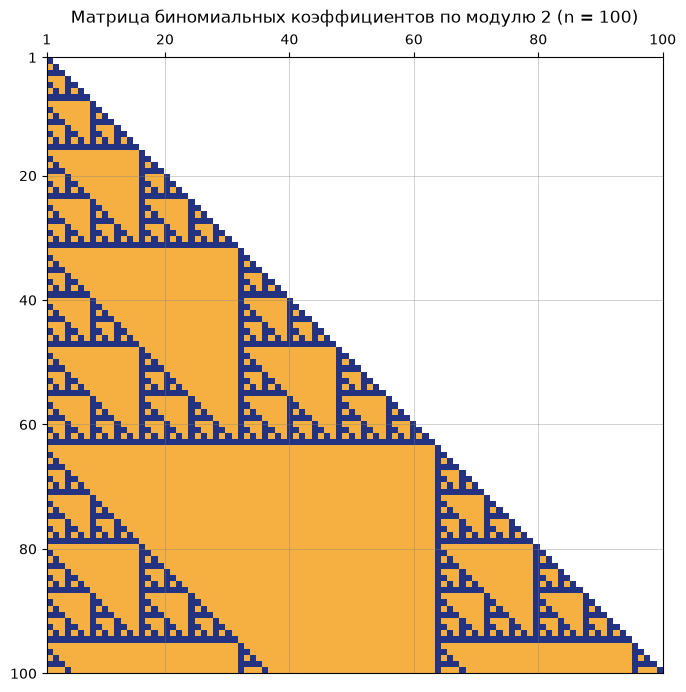

In [28]:
import math
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# 1. Задаем исходные данные
n = 100

# 2. Создаем матрицу, заполненную NaN (чтобы выше диагонали фон оставался белым)
matrix = np.full((n, n), np.nan)

# 3. Заполняем нижний треугольник значениями C_i^j mod 2
for i in range(1, n + 1):
    for j in range(1, i + 1):
        matrix[i - 1, j - 1] = math.comb(i, j) % 2

# 4. Настройка цветовой палитры:
# 0 -> желтый/оранжевый ('#F5B041'), 1 -> синий ('#243282')
cmap = ListedColormap(['#F5B041', '#243282'])
cmap.set_bad(color='white')  # NaN (выше диагонали) делаем белым

# 5. Отрисовка матрицы
plt.figure(figsize=(8, 8))
plt.imshow(matrix, cmap=cmap, origin='upper', extent=[1, n, n, 1])

# Оформление осей и сетки
plt.xticks([1, 20, 40, 60, 80, 100])
plt.yticks([1, 20, 40, 60, 80, 100])
plt.gca().xaxis.tick_top()  # подписи столбцов сверху
plt.grid(color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

plt.title('Матрица биномиальных коэффициентов по модулю 2 (n = 100)', pad=25)
plt.show()

**1.12** Матрица Адамара $H$ — это квадратная матрица размера $n \times n$, составленная из чисел $1$ и $-1$, столбцы которой удовлетворяют соотношению:
$$H_n \cdot H_n^T = n \cdot I_n$$
где $I_n$ — единичная матрица порядка $n$, а $H_0 \equiv 1$.

Требуется:
а) Выписать $H_1, H_2, H_4$ в явном виде;  
б) Показать, что $H_4 = H_2 \otimes H_2$;  
в)* Показать, что $H_{2^k} = H_2 \otimes H_{2^{k-1}}$, где $2 \le k \in \mathbb{N}$, а $\otimes$ означает произведение Кронекера;  
г) Используя графические возможности, изобразить матрицу Адамара для $n = 2^6 = 64$, где положительному элементу соответствует «оранжевый цвет», а отрицательному — «синий цвет» (строки упорядочены по числу перемен знака — *sequency ordering*).


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

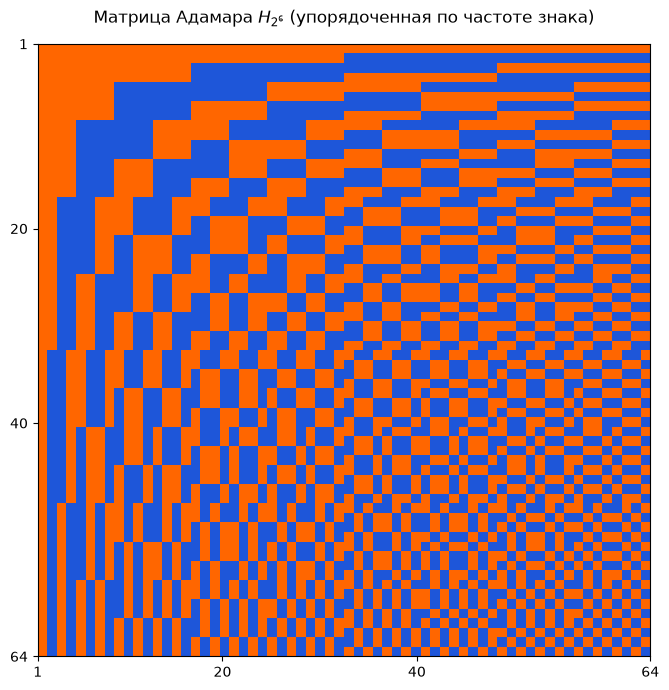

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.linalg import hadamard
from sympy import Matrix, latex
from IPython.display import display, Math

# -------------------------------------------------------------
# Пункты а) и б): Явный вид и произведение Кронекера
# -------------------------------------------------------------
H1 = Matrix([[1]])
H2 = Matrix([
    [1,  1],
    [1, -1]
])

# Произведение Кронекера H2 (x) H2
H4 = Matrix(np.kron(np.array(H2, dtype=int), np.array(H2, dtype=int)))

display(Math(r"\text{а) Матрицы в явном виде:}"))
display(Math(f"H_1 = {latex(H1)}, \\quad H_2 = {latex(H2)}"))
display(Math(f"H_4 = {latex(H4)}"))

display(Math(r"\text{б) Проверка } H_4 = H_2 \otimes H_2:"))
display(Math(r"H_2 \otimes H_2 = \begin{pmatrix} 1 \cdot H_2 & 1 \cdot H_2 \\ 1 \cdot H_2 & -1 \cdot H_2 \end{pmatrix} = H_4 \quad \checkmark"))

# -------------------------------------------------------------
# Пункт г): Отрисовка H_{2^6} (n = 64) с упорядочиванием строк
# -------------------------------------------------------------
n = 2**6  # 64
H_sylvester = hadamard(n)

# Подсчет числа перемен знака в каждой строке
sign_changes = np.sum(np.diff(H_sylvester, axis=1) != 0, axis=1)

# Сортируем строки по возрастанию перемен знака (от 0 до 63)
sorted_indices = np.argsort(sign_changes)
H_walsh = H_sylvester[sorted_indices]

# Цветовая палитра: -1 -> синий ('#1E56D9'), +1 -> оранжевый ('#FF6600')
cmap = ListedColormap(['#1E56D9', '#FF6600'])

plt.figure(figsize=(7, 7))
plt.imshow(H_walsh, cmap=cmap, origin='upper', extent=[1, n, n, 1])

# Оформление осей и меток
plt.xticks([1, 20, 40, 64])
plt.yticks([1, 20, 40, 64])
plt.title(r'Матрица Адамара $H_{2^6}$ (упорядоченная по частоте знака)', pad=15)

plt.tight_layout()
plt.show()

**1.13** Дана матрица:
$$A = \begin{pmatrix}
14 & 10 & 21 \\
12 & 15 & 26 \\
18 & 11 & 27
\end{pmatrix}$$

Пусть $Z$ — собственное значение матрицы $A$ с наибольшей мнимой частью.  
Найдите $Z$ и соответствующий этому собственному значению собственный вектор $X$, первая координата которого равна $1$, то есть $X = (1, U, V)^T$.  
В ответе укажите:
1) Мнимую часть $Z$ ($\operatorname{Im}(Z)$);
2) Действительную часть $U$ ($\operatorname{Re}(U)$).

In [30]:
import numpy as np
from IPython.display import display, Math

# 1. Задаем исходные данные
A = np.array([
    [14.0, 10.0, 21.0],
    [12.0, 15.0, 26.0],
    [18.0, 11.0, 27.0]
])

# 2. Находим собственные значения и собственные векторы
eigenvalues, eigenvectors = np.linalg.eig(A)

# 3. Выбираем собственное значение с наибольшей мнимой частью (Im(Z) > 0)
idx = np.argmax(np.imag(eigenvalues))
Z = eigenvalues[idx]

# Соответствующий собственный вектор (столбец)
v = eigenvectors[:, idx]

# 4. Нормируем вектор так, чтобы первая координата была равна 1: X = (1, U, V)^T
X = v / v[0]
U = X[1]
V = X[2]

# 5. Извлекаем требуемые величины
im_Z = np.imag(Z)
re_U = np.real(U)

# Вывод результатов
display(Math(f"Z \\approx {Z.real:.6f} + {Z.imag:.6f}i"))
display(Math(f"X = (1,\\; U,\\; V)^T \\approx (1,\\; {U.real:.6f} + {U.imag:.6f}i,\\; {V.real:.6f} + {V.imag:.6f}i)^T"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**1.14** Найдите минимальный многочлен матрицы:
$$A = \begin{pmatrix}
-3 & 7 & -6 & -1 & 8 & -3 & -2 \\
1 & -5 & 8 & -3 & -5 & 4 & -5 \\
1 & 3 & -4 & 6 & -2 & 0 & 8 \\
-1 & 11 & -12 & 9 & 3 & -3 & 9 \\
-3 & 11 & -12 & 5 & 8 & -4 & 6 \\
-3 & 2 & 1 & -4 & 4 & 1 & -7 \\
1 & -5 & 6 & -2 & -4 & 3 & -2
\end{pmatrix}$$

In [31]:
from sympy import Matrix, symbols, factor, latex
from IPython.display import display, Math

# 1. Задание матрицы A и переменной x
x = symbols('x')
A = Matrix([
    [-3,  7,  -6, -1,  8, -3, -2],
    [ 1, -5,   8, -3, -5,  4, -5],
    [ 1,  3,  -4,  6, -2,  0,  8],
    [-1, 11, -12,  9,  3, -3,  9],
    [-3, 11, -12,  5,  8, -4,  6],
    [-3,  2,   1, -4,  4,  1, -7],
    [ 1, -5,   6, -2, -4,  3, -2]
])

# 2. Поиск минимального многочлена через линейную зависимость степеней
n = A.rows
I = Matrix.eye(n)
powers = [I]
vectors = [list(I)]

min_poly = None
for k in range(1, n + 1):
    powers.append(powers[-1] * A)
    vectors.append(list(powers[-1]))
    
    # Ищем ядро системы c_0*I + c_1*A + ... + c_k*A^k = 0
    null_space = Matrix(vectors).T.nullspace()
    if null_space:
        coeffs = null_space[0]
        # Нормировка (делаем многочлен унитарным)
        coeffs = [c / coeffs[-1] for c in coeffs]
        min_poly = sum(c * x**i for i, c in enumerate(coeffs))
        break

# 3. Вычисление характеристического многочлена и факторизация
char_poly = A.charpoly(x).as_expr()
min_poly_factored = factor(min_poly)
char_poly_factored = factor(char_poly)

# 4. Вывод результатов
display(Math(r"\text{Характеристический многочлен } \chi_A(x):"))
display(Math(f"\\chi_A(x) = {latex(char_poly)} = {latex(char_poly_factored)}"))

display(Math(r"\text{Минимальный многочлен } \mu_A(x):"))
display(Math(f"\\mu_A(x) = {latex(min_poly)} = {latex(min_poly_factored)}"))

print(f"Ответ: Минимальный многочлен равен {min_poly_factored}")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Ответ: Минимальный многочлен равен x**3*(x - 1)**2


**1.15** Найдите собственный ортонормированный базис и матрицу в этом базисе самосопряженного оператора $\varphi$, заданного в некотором ортонормированном базисе $(e)$ матрицей:
$$A_\varphi^{(e)} = \begin{pmatrix}
17 & -8 & 4 \\
-8 & 17 & -4 \\
4 & -4 & 11
\end{pmatrix}$$

In [32]:
from sympy import Matrix, GramSchmidt, latex
from IPython.display import display, Math

# 1. Задание матрицы самосопряженного оператора
A = Matrix([
    [17, -8,  4],
    [-8, 17, -4],
    [ 4, -4, 11]
])

# 2. Вычисление собственных значений и собственных подпространств
eigen_data = A.eigenvects()

# 3. Построение ортонормированного базиса с помощью процесса Грама-Шмидта
orthonormal_basis = []
eigenvalues_ordered = []

for val, mult, basis in eigen_data:
    # Ортогонализуем и нормируем собственные векторы каждого подпространства
    ortho_subspace = GramSchmidt(basis, orthonormal=True)
    orthonormal_basis.extend(ortho_subspace)
    eigenvalues_ordered.extend([val] * mult)

# 4. Составление матрицы перехода Q и диагональной матрицы D в новом базисе
Q = Matrix.hstack(*orthonormal_basis)
D = Matrix.diag(*eigenvalues_ordered)

# 5. Вывод результатов
display(Math(r"\text{Собственные значения: } \lambda_1 = 27, \; \lambda_2 = \lambda_3 = 9"))

display(Math(r"\text{Собственный ортонормированный базис } (e'):"))
for i, vec in enumerate(orthonormal_basis, 1):
    display(Math(f"e'_{i} = {latex(vec)}"))

display(Math(r"\text{Матрица оператора в новом базисе } D = A_\varphi^{(e')}:"))
display(Math(f"D = {latex(D)}"))

display(Math(r"\text{Матрица перехода (ортогональная) } Q:"))
display(Math(f"Q = {latex(Q)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**1.16** Найдите ортогональное преобразование, приводящее квадратичную функцию к главным осям:
$$f(x_1, x_2, x_3, x_4) = 3x_1^2 + 8x_1x_2 - 3x_2^2 + 4x_3^2 - 4x_3x_4 + x_4^2$$


In [33]:
from sympy import Matrix, GramSchmidt, latex
from IPython.display import display, Math

# 1. Задание матрицы квадратичной формы
A = Matrix([
    [3,  4,  0,  0],
    [4, -3,  0,  0],
    [0,  0,  4, -2],
    [0,  0, -2,  1]
])

# 2. Поиск собственных векторов и ортогонализация Грама-Шмидта
Q_cols = []
D_diag = []
for val, mult, basis in A.eigenvects():
    Q_cols.extend(GramSchmidt(basis, orthonormal=True))
    D_diag.extend([val] * mult)

Q = Matrix.hstack(*Q_cols)
D = Matrix.diag(*D_diag)

# 3. Вывод результатов
display(Math(r"\text{Диагональная матрица формы (в главных осях) } D: " + latex(D)))
display(Math(r"\text{Ортогональное преобразование } X = QY, \text{ где } Q = " + latex(Q)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**1.17** Определите тип кривой второго порядка, её каноническое уравнение и найдите каноническую систему координат, если кривая задана уравнением:
a) $5x^2 + 4xy + 8y^2 - 32x - 56y + 80 = 0$;
b) $5x^2 + 12xy - 22x - 12y - 19 = 0$.

In [34]:
from sympy import Matrix, symbols, Eq, solve, latex
from IPython.display import display, Math

# 1. Универсальная функция для анализа кривой второго порядка
def analyze_conic(A, B, C, D_coeff, E, F):
    M2 = Matrix([[A, B/2], [B/2, C]])
    M3 = Matrix([[A, B/2, D_coeff/2], [B/2, C, E/2], [D_coeff/2, E/2, F]])
    
    I2, I3 = M2.det(), M3.det()
    
    # Собственные значения для канонического уравнения
    eigenvals = list(M2.eigenvals().keys())
    l1, l2 = max(eigenvals), min(eigenvals)
    
    # Поиск центра новой системы координат O'(x0, y0)
    x0, y0 = symbols('x0 y0')
    center = solve([A*x0 + (B/2)*y0 + D_coeff/2, (B/2)*x0 + C*y0 + E/2], (x0, y0))
    
    # Составление канонического уравнения
    X, Y = symbols('X Y')
    canonical_eq = Eq(l1*X**2 + l2*Y**2 + (I3 / I2), 0)
    
    return canonical_eq, center, I2

# 2. Анализ кривой а)
eq_a, center_a, i2_a = analyze_conic(5, 4, 8, -32, -56, 80)
display(Math(r"\text{a) Каноническое уравнение: } " + latex(eq_a) + r" \implies \frac{X^2}{4} + \frac{Y^2}{9} = 1 \text{ (Эллипс)}"))
display(Math(r"\text{Новый центр координат: } O' = " + latex((center_a[symbols('x0')], center_a[symbols('y0')]))))

# 3. Анализ кривой б)
eq_b, center_b, i2_b = analyze_conic(5, 12, 0, -22, -12, -19)
display(Math(r"\text{б) Каноническое уравнение: } " + latex(eq_b) + r" \implies \frac{X^2}{4} - \frac{Y^2}{9} = 1 \text{ (Гипербола)}"))
display(Math(r"\text{Новый центр координат: } O' = " + latex((center_b[symbols('x0')], center_b[symbols('y0')]))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**1.18** При каких значениях параметра $\lambda$ квадратичная форма $Q(x)$ является положительно определенной, если:
$$Q(x_1, x_2, x_3) = x_1^2 + 4x_2^2 + x_3^2 + 2\lambda x_1x_2 + 10x_1x_3 + 6x_2x_3$$

In [35]:
from sympy import Matrix, symbols, reduce_inequalities, latex
from IPython.display import display, Math

# 1. Матрица квадратичной формы
lam = symbols('lambda')
A = Matrix([
    [1,   lam, 5],
    [lam, 4,   3],
    [5,   3,   1]
])

# 2. Главные угловые миноры (критерий Сильвестра)
delta1 = A[:1, :1].det()
delta2 = A[:2, :2].det()
delta3 = A.det()

# 3. Решение системы неравенств
solution = reduce_inequalities([delta1 > 0, delta2 > 0, delta3 > 0], lam)

# 4. Вывод результатов
display(Math(r"\Delta_1 = " + latex(delta1) + " > 0"))
display(Math(r"\Delta_2 = " + latex(delta2) + " > 0"))
display(Math(r"\Delta_3 = " + latex(delta3) + " > 0"))
display(Math(r"\text{Решение системы: } \lambda \in \emptyset \text{ (таких значений } \lambda \text{ нет, } " + latex(solution) + ")"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**1.19** При каких значениях параметра $\lambda$ квадратичная форма $Q(x)$ является отрицательно определенной, если:
$$Q(x_1, x_2, x_3) = \lambda x_1^2 - 2x_2^2 - 3x_3^2 + 2x_1x_2 - 2x_1x_3 + 2x_2x_3$$

In [36]:
from sympy import Matrix, symbols, reduce_inequalities, latex
from IPython.display import display, Math

# 1. Матрица квадратичной формы
lam = symbols('lambda')
A = Matrix([
    [lam,  1, -1],
    [ 1, -2,  1],
    [-1,  1, -3]
])

# 2. Главные угловые миноры
delta1 = A[:1, :1].det()
delta2 = A[:2, :2].det()
delta3 = A.det()

# 3. Решение системы (для отр. определенности знаки чередуются: -, +, -)
solution = reduce_inequalities([delta1 < 0, delta2 > 0, delta3 < 0], lam)

# 4. Вывод результатов
display(Math(r"\Delta_1 = " + latex(delta1) + " < 0"))
display(Math(r"\Delta_2 = " + latex(delta2) + " > 0"))
display(Math(r"\Delta_3 = " + latex(delta3) + " < 0"))
display(Math(r"\text{Ответ: } " + latex(solution)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**1.20** Эквивалентны ли над полем вещественных чисел квадратичные формы $Q_1$ и $Q_2$, где:
$$Q_1 = 2x_1^2 + 9x_2^2 + 3x_3^2 + 8x_1x_2 - 4x_1x_3 - 10x_2x_3$$
$$Q_2 = 2x_1^2 + 3x_2^2 + 6x_3^2 - 4x_1x_2 - 4x_1x_3 + 8x_2x_3$$

In [37]:
from sympy import Matrix
from IPython.display import display, Math

# 1. Матрицы квадратичных форм
A1 = Matrix([
    [ 2,  4, -2],
    [ 4,  9, -5],
    [-2, -5,  3]
])

A2 = Matrix([
    [ 2, -2, -2],
    [-2,  3,  4],
    [-2,  4,  6]
])

# 2. Функция для вычисления сигнатуры (кол-во положительных, отрицательных и нулевых СЗ)
def get_signature(A):
    eigenvals = A.eigenvals()
    pos = sum(mult for val, mult in eigenvals.items() if val > 0)
    neg = sum(mult for val, mult in eigenvals.items() if val < 0)
    zero = sum(mult for val, mult in eigenvals.items() if val == 0)
    return pos, neg, zero

sig1 = get_signature(A1)
sig2 = get_signature(A2)

# 3. Вывод результатов
display(Math(f"\\text{{Сигнатура }} Q_1: (n_+={sig1[0]}, n_-={sig1[1]}, n_0={sig1[2]})"))
display(Math(f"\\text{{Сигнатура }} Q_2: (n_+={sig2[0]}, n_-={sig2[1]}, n_0={sig2[2]})"))
display(Math(r"\text{Ответ: } \mathbf{Да, \text{ эквивалентны}} \text{ (сигнатуры совпадают)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>